# RoPE Recency Bias Analysis

Phoenix uses **Rotary Position Embeddings (RoPE)** (`RotaryEmbedding` in `grok.py`, `base_exponent=1e4`) applied to queries and keys before computing attention scores.

RoPE encodes position by rotating key/query vectors. The dot product between a query at position $i$ and a key at position $j$ picks up a positional modulation:
$$\text{bias}(i, j) = \sum_{d=0}^{D/2-1} 2\cos\!\left(\frac{i - j}{10000^{\,2d/D}}\right)$$

This means **nearby positions score higher than distant ones** — an implicit recency bias. Recent history tokens attract stronger attention from every query, including candidates attending to user history.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters match grok.py exactly
BASE = 1e4
D    = 16    # key_size used in the attn-mask.ipynb experiments
SEQ  = 20   # sequence length to visualise

d_idx    = np.arange(0, D, 2)             # [0, 2, 4, ..., D-2]
inv_freq = 1.0 / (BASE ** (d_idx / D))   # per-dimension frequencies

print(f'key_size = {D},  base_exponent = {BASE:.0f}')
print(f'inv_freq: {inv_freq.round(4)}')

key_size = 16,  base_exponent = 10000
inv_freq: [1.000e+00 3.162e-01 1.000e-01 3.160e-02 1.000e-02 3.200e-03 1.000e-03
 3.000e-04]


In [2]:
# Build the full position x position bias matrix
# bias[i, j] = sum over d of 2*cos((i-j)*inv_freq[d])
positions = np.arange(SEQ)
bias = np.array([[2 * np.sum(np.cos((i - j) * inv_freq))
                  for j in positions] for i in positions])

# Normalise: self-similarity (i==j) = 1.0
bias_norm = bias / bias[0, 0]
print(f'Self-similarity (distance 0): {bias[0,0]:.1f}  (= D = {D})')

Self-similarity (distance 0): 16.0  (= D = 16)


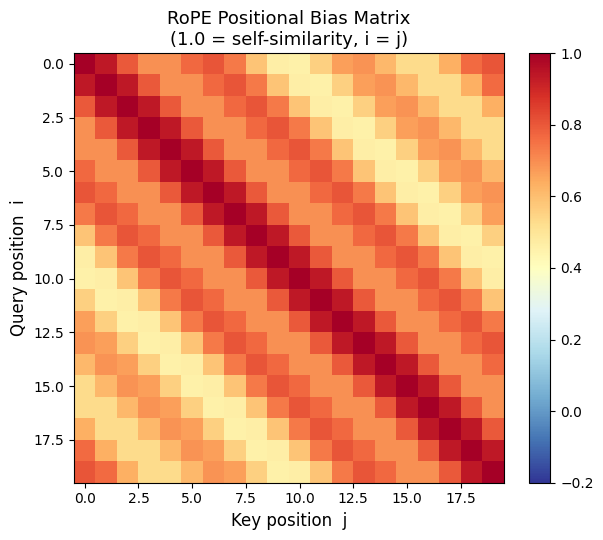

In [3]:
# Plot 1 — heatmap of positional bias
fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(bias_norm, cmap='RdYlBu_r', vmin=-0.2, vmax=1.0, interpolation='nearest')
ax.set_xlabel('Key position  j', fontsize=12)
ax.set_ylabel('Query position  i', fontsize=12)
ax.set_title('RoPE Positional Bias Matrix\n(1.0 = self-similarity, i = j)', fontsize=13)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

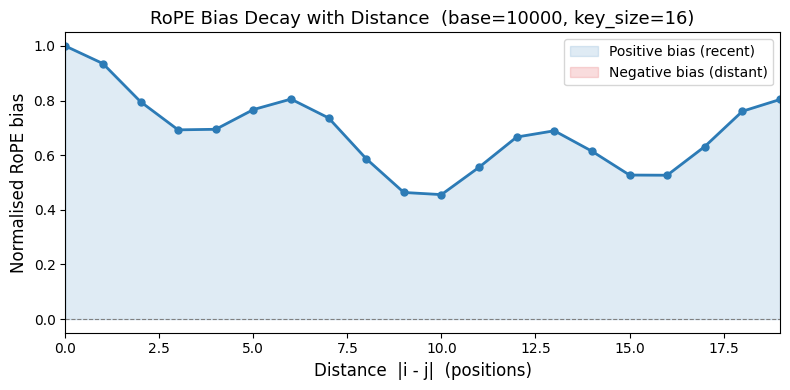

Bias at distance  1: 0.936
Bias at distance  5: 0.767
Bias at distance 10: 0.456
First goes negative at distance: 0


In [4]:
# Plot 2 — decay curve: bias as a function of distance |i - j|
deltas     = np.arange(SEQ)
decay      = np.array([2 * np.sum(np.cos(d * inv_freq)) for d in deltas])
decay_norm = decay / decay[0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(deltas, decay_norm, 'o-', color='#2c7bb6', linewidth=2, markersize=5)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.fill_between(deltas, decay_norm, 0, where=(decay_norm >= 0),
                alpha=0.15, color='#2c7bb6', label='Positive bias (recent)')
ax.fill_between(deltas, decay_norm, 0, where=(decay_norm < 0),
                alpha=0.15, color='#d7191c', label='Negative bias (distant)')
ax.set_xlabel('Distance  |i - j|  (positions)', fontsize=12)
ax.set_ylabel('Normalised RoPE bias', fontsize=12)
ax.set_title(f'RoPE Bias Decay with Distance  (base={BASE:.0f}, key_size={D})', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0, SEQ - 1)
plt.tight_layout()
plt.show()

zero_cross = int(np.argmax(decay_norm < 0))
print(f'Bias at distance  1: {decay_norm[1]:.3f}')
print(f'Bias at distance  5: {decay_norm[5]:.3f}')
print(f'Bias at distance 10: {decay_norm[10]:.3f}')
print(f'First goes negative at distance: {zero_cross}')

## Interpretation

**Recency bias in user history**: Candidate tokens attend to positions `0 ... candidate_start_offset-1` (user + history). Because RoPE decays with distance, the most recent history tokens receive higher attention scores than older ones, all else equal.

**Smooth decay, not a hard cutoff**: The decay follows a sum-of-cosines and may oscillate slightly negative at larger distances. The effective recency window depends on `base_exponent` and `key_size`.

**Interaction with candidate isolation**: The recency bias operates *within* the attended positions (user+history). The attention mask already prevents candidates from seeing each other, so RoPE only affects how a candidate weighs different history tokens.